# XSS Detection Pipeline
Detecting XSS-Prone Patterns in AI-Generated JavaScript Using Machine Learning

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedShuffleSplit, StratifiedKFold, cross_validate
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, precision_recall_fscore_support)

In [2]:
# Load dataset
df = pd.read_csv('../data/dataset_labelled.csv')
print(f'Total snippets: {len(df)}')
print(f'Vulnerable: {df.label.sum()}')
print(f'Safe: {len(df) - df.label.sum()}')
print()
print('Category breakdown:')
print(df.groupby('task_category')['label'].agg(['count','sum',lambda x:(x==0).sum()]).
      rename(columns={'count':'Total','sum':'Vulnerable','<lambda_0>':'Safe'}).
      sort_values('Total', ascending=False).to_string())

Total snippets: 250
Vulnerable: 124
Safe: 126

Category breakdown:
                                 Total  Vulnerable  Safe
task_category                                           
URL query parameter display         22          10    12
GitHub - real world                 22          11    11
Username welcome message            21          11    10
User comment rendering              20          10    10
Search term heading                 19           9    10
Form input live preview             18           9     9
Error message from URL hash         17           9     8
User profile card rendering         16           7     9
Referrer message display            15           7     8
Tag and filter display from URL     14           7     7
Dynamic link href from URL          12           6     6
Server response rendering           11           6     5
Image src from user input            9           4     5
LocalStorage data display            8           4     4
iframe content inject

In [3]:
# Tokenisation and TF-IDF
# Compound security tokens are joined with _ so regex keeps them as single units
SECURITY_TOKENS = [
    'innerHTML', 'outerHTML', 'document.write', 'document.writeln',
    'insertAdjacentHTML', 'dangerouslySetInnerHTML',
    'textContent', 'innerText', 'createTextNode',
    'DOMPurify', 'sanitize', 'encodeURIComponent',
    'location.search', 'location.hash', 'location.href',
    'document.referrer',
    'localStorage.getItem', 'sessionStorage.getItem',
    'setAttribute', 'addEventListener',
    'event.data'
]

def tokenise(code):
    for token in SECURITY_TOKENS:
        code = code.replace(token, token.replace('.', '_'))
    tokens = re.findall(r'[a-zA-Z_][a-zA-Z0-9_]*', code)
    return ' '.join(tokens)

df['tokens'] = df['code'].apply(tokenise)

vectoriser = TfidfVectorizer(min_df=2, max_df=0.95, max_features=500)
X = vectoriser.fit_transform(df['tokens'])
y = df['label'].values

print(f'Feature matrix: {X.shape[0]} snippets x {X.shape[1]} tokens')

Feature matrix: 250 snippets x 176 tokens


In [4]:
# Train/test split - stratified by task category
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(sss.split(X, df['task_category'].values))

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

print(f'Train: {X_train.shape[0]} | Test: {X_test.shape[0]}')
print(f'\nTest set categories:')
print(df.iloc[test_idx]['task_category'].value_counts().to_string())
print(f'\nTest set labels:')
print(df.iloc[test_idx]['label'].value_counts().to_string())

Train: 200 | Test: 50

Test set categories:
task_category
URL query parameter display        5
Username welcome message           4
GitHub - real world                4
Form input live preview            4
Search term heading                4
User comment rendering             4
Tag and filter display from URL    3
Error message from URL hash        3
User profile card rendering        3
Referrer message display           3
Dynamic link href from URL         2
LocalStorage data display          2
iframe content injection           2
Image src from user input          2
Server response rendering          2
PostMessage handler                1
Dynamic script execution           1
Inline event handler binding       1

Test set labels:
label
1    25
0    25


=== Logistic Regression ===
              precision    recall  f1-score   support

        Safe       0.86      1.00      0.93        25
  Vulnerable       1.00      0.84      0.91        25

    accuracy                           0.92        50
   macro avg       0.93      0.92      0.92        50
weighted avg       0.93      0.92      0.92        50



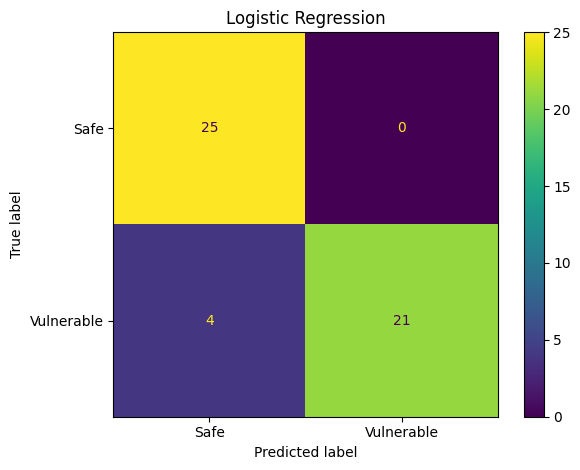

In [5]:
# Logistic Regression
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print('=== Logistic Regression ===')
print(classification_report(y_test, y_pred_lr, target_names=['Safe','Vulnerable']))

cm_lr = confusion_matrix(y_test, y_pred_lr)
ConfusionMatrixDisplay(cm_lr, display_labels=['Safe','Vulnerable']).plot()
plt.title('Logistic Regression')
plt.tight_layout()
plt.savefig('../data/cm_lr.png')
plt.show()

=== Random Forest ===
              precision    recall  f1-score   support

        Safe       0.83      1.00      0.91        25
  Vulnerable       1.00      0.80      0.89        25

    accuracy                           0.90        50
   macro avg       0.92      0.90      0.90        50
weighted avg       0.92      0.90      0.90        50



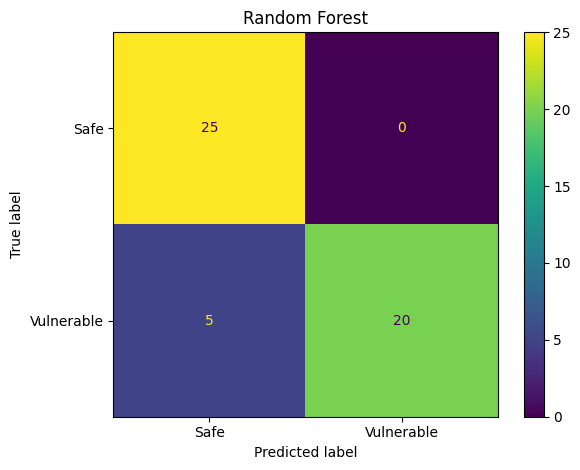

In [6]:
# Random Forest
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print('=== Random Forest ===')
print(classification_report(y_test, y_pred_rf, target_names=['Safe','Vulnerable']))

cm_rf = confusion_matrix(y_test, y_pred_rf)
ConfusionMatrixDisplay(cm_rf, display_labels=['Safe','Vulnerable']).plot()
plt.title('Random Forest')
plt.tight_layout()
plt.savefig('../data/cm_rf.png')
plt.show()

=== 5-Fold Cross-Validation ===

Logistic Regression:
  Precision: 0.847 (+/- 0.078)
     Recall: 0.847 (+/- 0.068)
         F1: 0.843 (+/- 0.048)

Random Forest:
  Precision: 0.840 (+/- 0.046)
     Recall: 0.855 (+/- 0.086)
         F1: 0.843 (+/- 0.035)


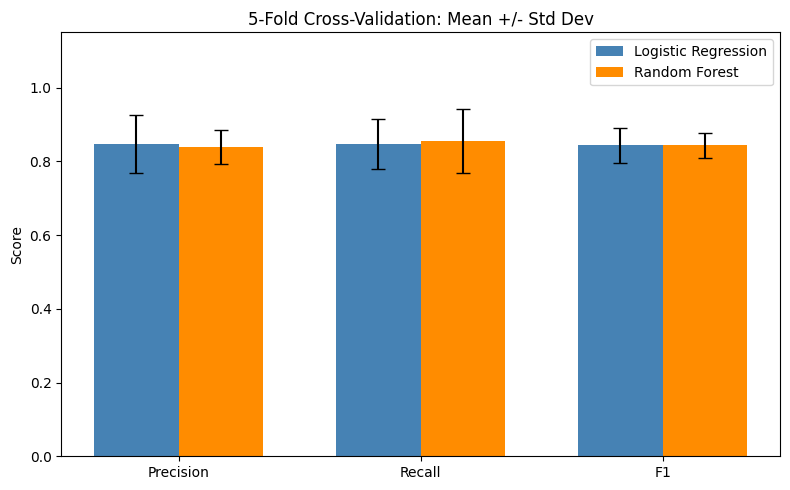

In [7]:
# 5-Fold Cross-Validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

lr_cv = cross_validate(
    LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    X, y, cv=cv,
    scoring=['precision', 'recall', 'f1'],
    return_train_score=False
)

rf_cv = cross_validate(
    RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
    X, y, cv=cv,
    scoring=['precision', 'recall', 'f1'],
    return_train_score=False
)

print('=== 5-Fold Cross-Validation ===')
for name, res in [('Logistic Regression', lr_cv), ('Random Forest', rf_cv)]:
    print(f'\n{name}:')
    for metric in ['precision', 'recall', 'f1']:
        vals = res[f'test_{metric}']
        print(f'  {metric.capitalize():>9}: {vals.mean():.3f} (+/- {vals.std():.3f})')

# Plot
metrics = ['Precision', 'Recall', 'F1']
lr_means = [lr_cv[f'test_{m.lower()}'].mean() for m in metrics]
lr_stds  = [lr_cv[f'test_{m.lower()}'].std()  for m in metrics]
rf_means = [rf_cv[f'test_{m.lower()}'].mean() for m in metrics]
rf_stds  = [rf_cv[f'test_{m.lower()}'].std()  for m in metrics]

x = np.arange(len(metrics))
width = 0.35
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width/2, lr_means, width, yerr=lr_stds, label='Logistic Regression', capsize=5, color='steelblue')
ax.bar(x + width/2, rf_means, width, yerr=rf_stds, label='Random Forest', capsize=5, color='darkorange')
ax.set_ylim(0, 1.15)
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylabel('Score')
ax.set_title('5-Fold Cross-Validation: Mean +/- Std Dev')
ax.legend()
plt.tight_layout()
plt.savefig('../data/cv_results.png')
plt.show()

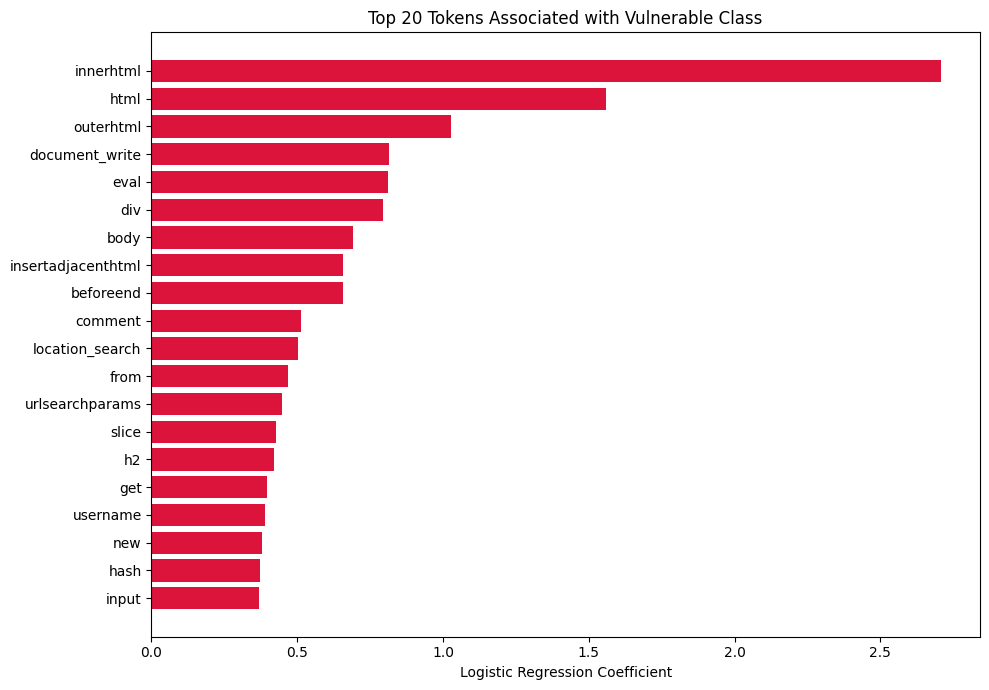

Top 10 tokens associated with VULNERABLE class:
  innerhtml: 2.7065
  html: 1.5605
  outerhtml: 1.0270
  document_write: 0.8138
  eval: 0.8130
  div: 0.7949
  body: 0.6917
  insertadjacenthtml: 0.6571
  beforeend: 0.6571
  comment: 0.5129

Top 10 tokens associated with SAFE class:
  innertext: -2.2381
  textcontent: -2.1998
  safe: -1.2335
  setattribute: -0.7864
  replace: -0.7192
  if: -0.6419
  getelementbyid: -0.6313
  com: -0.6274
  replacechildren: -0.6014
  https: -0.5638


In [8]:
# Feature importance - logistic regression coefficients
feature_names = vectoriser.get_feature_names_out()
coefs = lr.coef_[0]

# Top 20 positive (vulnerable class)
top_idx = np.argsort(coefs)[-20:][::-1]
top_tokens = [feature_names[i] for i in top_idx]
top_weights = [coefs[i] for i in top_idx]

plt.figure(figsize=(10, 7))
plt.barh(top_tokens[::-1], top_weights[::-1], color='crimson')
plt.xlabel('Logistic Regression Coefficient')
plt.title('Top 20 Tokens Associated with Vulnerable Class')
plt.tight_layout()
plt.savefig('../data/feature_importance.png')
plt.show()

print('Top 10 tokens associated with VULNERABLE class:')
for t, w in zip(top_tokens[:10], top_weights[:10]):
    print(f'  {t}: {w:.4f}')

# Bottom (safe class)
bot_idx = np.argsort(coefs)[:10]
bot_tokens = [feature_names[i] for i in bot_idx]
bot_weights = [coefs[i] for i in bot_idx]

print('\nTop 10 tokens associated with SAFE class:')
for t, w in zip(bot_tokens[:10], bot_weights[:10]):
    print(f'  {t}: {w:.4f}')

=== Rule-Based Baseline ===
              precision    recall  f1-score   support

        Safe       0.69      1.00      0.82        25
  Vulnerable       1.00      0.56      0.72        25

    accuracy                           0.78        50
   macro avg       0.85      0.78      0.77        50
weighted avg       0.85      0.78      0.77        50



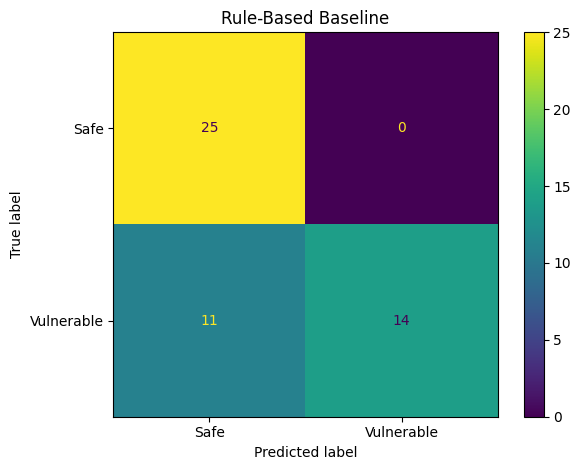

In [9]:
# Rule-based baseline
# Simulates token-proximity matching like a basic linter.
# Checks if a known source appears near a known dangerous sink.
# Cannot follow data through intermediate variables.

UNSAFE_SINKS = [
    'innerHTML', 'outerHTML', 'document.write', 'document.writeln',
    'insertAdjacentHTML',
]

SOURCES = [
    'location.search', 'location.hash', 'location.href',
    'document.referrer', '.value', 'props.',
]

SANITISERS = [
    'DOMPurify', 'sanitize', 'createTextNode',
    'textContent', 'innerText',
]

def rule_baseline(code):
    # If a sanitiser appears anywhere, assume safe
    if any(s in code for s in SANITISERS):
        return 0
    # Check if any source appears within 80 chars of any sink
    for sink in UNSAFE_SINKS:
        idx = code.find(sink)
        while idx != -1:
            window = code[max(0, idx-80):idx+80]
            if any(src in window for src in SOURCES):
                return 1
            idx = code.find(sink, idx+1)
    return 0

# Run on test set
test_df_baseline = df.iloc[test_idx].copy()
baseline_preds = [rule_baseline(row['code']) for _, row in test_df_baseline.iterrows()]

print('=== Rule-Based Baseline ===')
print(classification_report(y_test, baseline_preds, target_names=['Safe','Vulnerable']))

cm_bl = confusion_matrix(y_test, baseline_preds)
ConfusionMatrixDisplay(cm_bl, display_labels=['Safe','Vulnerable']).plot()
plt.title('Rule-Based Baseline')
plt.tight_layout()
plt.savefig('../data/cm_eslint.png')
plt.show()

Expanded rule baseline (with broader OWASP tokens):
              precision    recall  f1-score   support

        Safe       0.78      1.00      0.88        25
  Vulnerable       1.00      0.72      0.84        25

    accuracy                           0.86        50
   macro avg       0.89      0.86      0.86        50
weighted avg       0.89      0.86      0.86        50



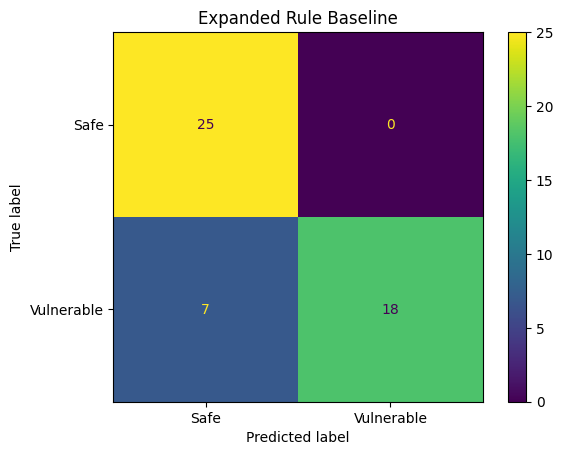

In [10]:
# Expanded rule baseline (added in response to symmetric-comparison check, see Section 3.6)
# Same proximity logic as the original rule, but with broader OWASP-derived tokens

EXP_SINKS = UNSAFE_SINKS + [
    'eval(', 'srcdoc', 'dangerouslySetInnerHTML',
    '.html(',         # jQuery .html()
    '.append(',       # jQuery .append()
    'new Function('   # Function constructor
]

EXP_SOURCES = SOURCES + [
    'URLSearchParams', 'event.data',
    'localStorage.getItem', 'sessionStorage.getItem',
    'document.URL', 'window.name'
]

EXP_SANITISERS = SANITISERS + [
    'encodeURIComponent', 'escape(', 'he.encode'
]

def expanded_rule_baseline(code):
    """Same proximity logic as rule_baseline (Cell 9), but with the expanded token sets."""
    if any(s in code for s in EXP_SANITISERS):
        return 0
    for sink in EXP_SINKS:
        idx = code.find(sink)
        while idx != -1:
            window = code[max(0, idx-80):idx+80]
            if any(src in window for src in EXP_SOURCES):
                return 1
            idx = code.find(sink, idx+1)
    return 0

expanded_preds = [expanded_rule_baseline(row['code'])
                  for _, row in df.iloc[test_idx].iterrows()]

print("Expanded rule baseline (with broader OWASP tokens):")
print(classification_report(y_test, expanded_preds, target_names=['Safe','Vulnerable']))

cm_expanded = confusion_matrix(y_test, expanded_preds)
ConfusionMatrixDisplay(cm_expanded, display_labels=['Safe','Vulnerable']).plot()
plt.title('Expanded Rule Baseline')
plt.savefig('../data/cm_expanded_rule.png')
plt.show()


                                  Precision  Recall     F1
Logistic Regression                     1.0    0.84  0.913
Random Forest                           1.0    0.80  0.889
Rule-Based (original, 16 tokens)        1.0    0.56  0.718
Rule-Based (expanded, OWASP)            1.0    0.72  0.837


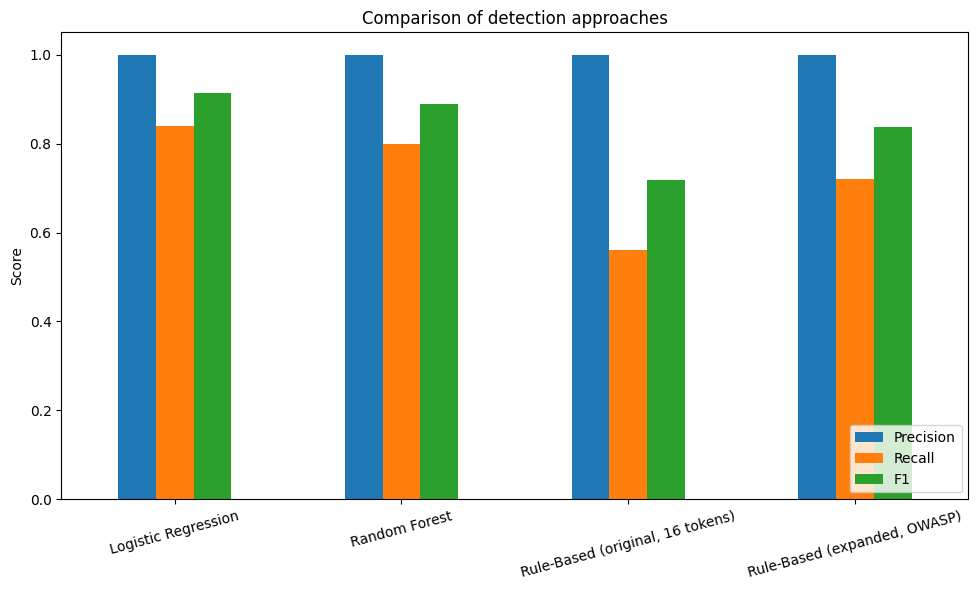

In [11]:
# Comparison across all four approaches (LR, RF, original rule, expanded rule)
def get_metrics(y_true, y_pred):
    p, r, f, _ = precision_recall_fscore_support(y_true, y_pred, average='binary')
    return {'Precision': round(p, 3), 'Recall': round(r, 3), 'F1': round(f, 3)}

results = pd.DataFrame({
    'Logistic Regression': get_metrics(y_test, y_pred_lr),
    'Random Forest': get_metrics(y_test, y_pred_rf),
    'Rule-Based (original, 16 tokens)': get_metrics(y_test, baseline_preds),
    'Rule-Based (expanded, OWASP)': get_metrics(y_test, expanded_preds)
}).T

print(results)

# Bar chart
ax = results.plot(kind='bar', figsize=(10, 6), rot=15)
plt.title('Comparison of detection approaches')
plt.ylabel('Score')
plt.ylim(0, 1.05)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('../data/comparison.png')
plt.show()


In [12]:
# Disagreement analysis
best_preds = y_pred_lr if results.loc['Logistic Regression','F1'] >= results.loc['Random Forest','F1'] else y_pred_rf

test_df = df.iloc[test_idx].copy()
test_df['ground_truth'] = y_test
test_df['ml_prediction'] = best_preds
test_df['baseline_prediction'] = baseline_preds

disagreements = test_df[test_df['ml_prediction'] != test_df['baseline_prediction']]
print(f'Total disagreements: {len(disagreements)}')

# Break down: ML right vs baseline right
ml_wins = disagreements[(disagreements['ml_prediction'] == disagreements['ground_truth']) & 
                        (disagreements['baseline_prediction'] != disagreements['ground_truth'])]
bl_wins = disagreements[(disagreements['baseline_prediction'] == disagreements['ground_truth']) & 
                        (disagreements['ml_prediction'] != disagreements['ground_truth'])]

print(f'ML correct, baseline wrong: {len(ml_wins)}')
print(f'Baseline correct, ML wrong: {len(bl_wins)}')
print()

disagreements[['snippet_id','task_category','ml_prediction','baseline_prediction','ground_truth','sink']]

Total disagreements: 7
ML correct, baseline wrong: 7
Baseline correct, ML wrong: 0



,snippet_id,task_category,ml_prediction,baseline_prediction,ground_truth,sink
182,snippet_260,GitHub - real world,1,0,1,DANGEROUS:jQuery.html()
143,snippet_221,Form input live preview,1,0,1,DANGEROUS:Function() constructor
208,snippet_286,iframe content injection,1,0,1,DANGEROUS:iframe.srcdoc
150,snippet_228,Username welcome message,1,0,1,DANGEROUS:setTimeout(string)
206,snippet_284,iframe content injection,1,0,1,DANGEROUS:iframe.srcdoc
222,snippet_300,Dynamic script execution,1,0,1,DANGEROUS:setTimeout(string)
226,snippet_304,Server response rendering,1,0,1,DANGEROUS:innerHTML
